In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Check if df exists, if not, generate dummy data
try:
    df
    print("df already exists")
except NameError:
    print("df does not exist, generating dummy data")
    # Generate dummy data
    np.random.seed(42)
    n = 1000
    start_time = datetime.now()
    timestamps = [start_time + timedelta(minutes=i) for i in range(n)]
    
    # Simulate mid_price with some trend and noise
    mid_price = 100 + np.cumsum(np.random.randn(n) * 0.1) + np.sin(np.arange(n) * 0.01) * 5
    
    # trade_price close to mid_price
    trade_price = mid_price + np.random.randn(n) * 0.05
    
    # trade_size random
    trade_size = np.random.exponential(10, n)
    
    # bid_ask_spread_bps
    bid_ask_spread_bps = np.random.uniform(1, 10, n)
    
    # bid_depth and ask_depth
    bid_depth = np.random.exponential(100, n)
    ask_depth = np.random.exponential(100, n)
    
    # signed_volume: positive for buy, negative for sell
    signed_volume = np.random.choice([-1, 1], n) * trade_size
    
    # order_imbalance: between -1 and 1
    order_imbalance = np.random.uniform(-1, 1, n)
    
    df = pd.DataFrame({
        'timestamp': timestamps,
        'mid_price': mid_price,
        'trade_price': trade_price,
        'trade_size': trade_size,
        'bid_ask_spread_bps': bid_ask_spread_bps,
        'bid_depth': bid_depth,
        'ask_depth': ask_depth,
        'signed_volume': signed_volume,
        'order_imbalance': order_imbalance
    })

print(df.head())

df already exists
                   timestamp   mid_price  trade_price  trade_size  \
0 2026-03-20 10:02:04.445146  100.049671   100.119639    5.227405   
1 2026-03-20 10:03:04.445146  100.085844   100.132076    0.682894   
2 2026-03-20 10:04:04.445146  100.200607   100.203589    4.289700   
3 2026-03-20 10:05:04.445146  100.402894   100.370547    1.176559   
4 2026-03-20 10:06:04.445146  100.429448   100.464359   16.514857   

   bid_ask_spread_bps   bid_depth   ask_depth  signed_volume  order_imbalance  
0            3.721776  110.526396   29.770442       5.227405        -0.589626  
1            6.070675  160.273930   14.579077       0.682894        -0.025835  
2            8.234244  269.938196   30.117001       4.289700         0.756505  
3            2.234336    2.034338   48.622742      -1.176559         0.054510  
4            6.226292   16.698028  286.440202     -16.514857         0.859741  


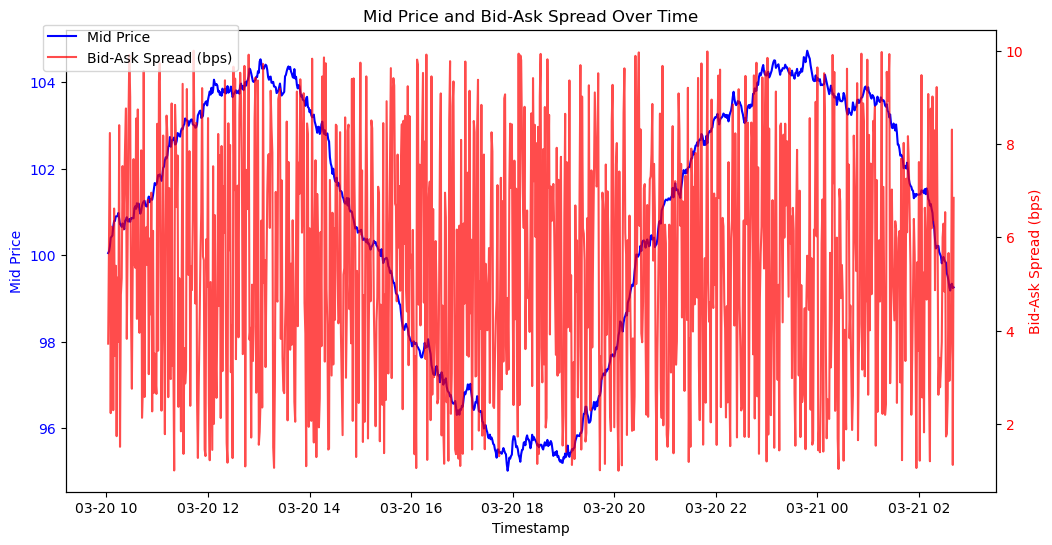

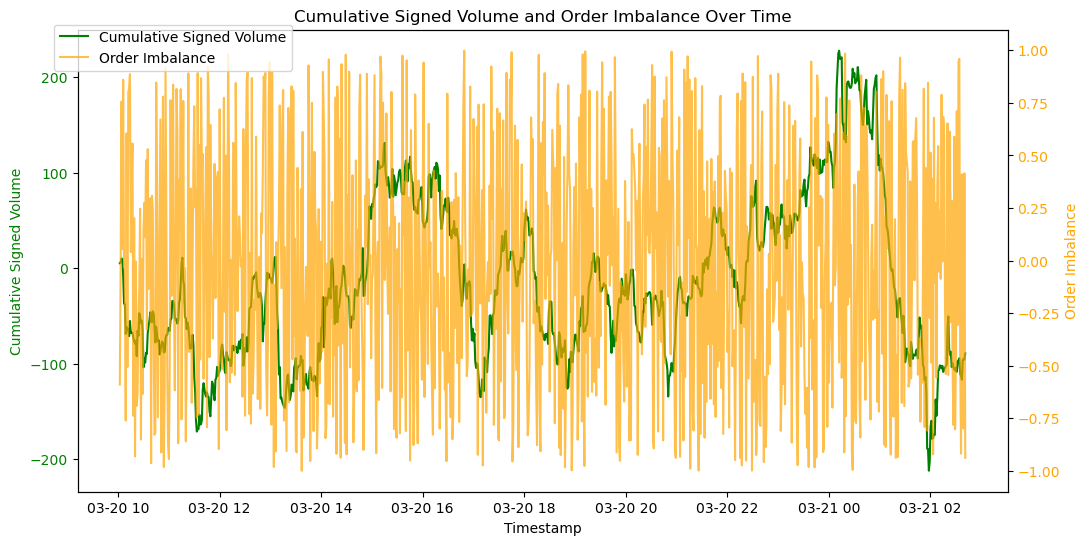

In [4]:
# Proposal 1: Time series of Mid Price and Bid-Ask Spread
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df['timestamp'], df['mid_price'], label='Mid Price', color='blue')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Mid Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(df['timestamp'], df['bid_ask_spread_bps'], label='Bid-Ask Spread (bps)', color='red', alpha=0.7)
ax2.set_ylabel('Bid-Ask Spread (bps)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Mid Price and Bid-Ask Spread Over Time')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

# Proposal 2: Cumulative Signed Volume and Order Imbalance
fig, ax1 = plt.subplots(figsize=(12, 6))

cum_signed_volume = df['signed_volume'].cumsum()
ax1.plot(df['timestamp'], cum_signed_volume, label='Cumulative Signed Volume', color='green')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Cumulative Signed Volume', color='green')
ax1.tick_params(axis='y', labelcolor='green')

ax2 = ax1.twinx()
ax2.plot(df['timestamp'], df['order_imbalance'], label='Order Imbalance', color='orange', alpha=0.7)
ax2.set_ylabel('Order Imbalance', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Cumulative Signed Volume and Order Imbalance Over Time')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

df already exists
Missing columns: ['future_mid_return_1min', 'future_mid_return_5min', 'spread_bps', 'depth_total', 'realized_vol_5min', 'lagged_return_1min'], generating them
                   timestamp   mid_price  trade_price  trade_size  \
0 2026-03-20 10:02:04.445146  100.049671   100.119639    5.227405   
1 2026-03-20 10:03:04.445146  100.085844   100.132076    0.682894   
2 2026-03-20 10:04:04.445146  100.200607   100.203589    4.289700   
3 2026-03-20 10:05:04.445146  100.402894   100.370547    1.176559   
4 2026-03-20 10:06:04.445146  100.429448   100.464359   16.514857   

   bid_ask_spread_bps   bid_depth   ask_depth  signed_volume  order_imbalance  \
0            3.721776  110.526396   29.770442       5.227405        -0.589626   
1            6.070675  160.273930   14.579077       0.682894        -0.025835   
2            8.234244  269.938196   30.117001       4.289700         0.756505   
3            2.234336    2.034338   48.622742      -1.176559         0.054510   
4  

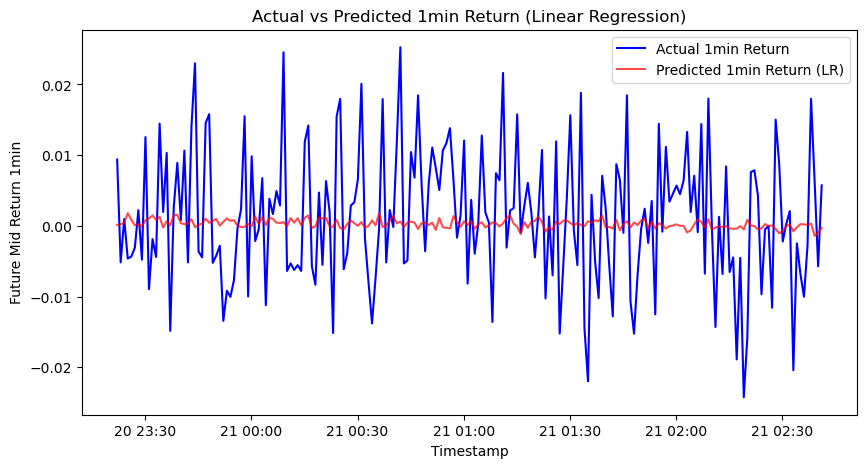

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta

# Check if df exists, if not, generate dummy data
try:
    df
    print("df already exists")
    # Check if required columns exist, if not, add them
    required_columns = ['timestamp', 'mid_price', 'future_mid_return_1min', 'future_mid_return_5min', 'spread_bps', 'depth_total', 'signed_volume', 'order_imbalance', 'realized_vol_5min', 'lagged_return_1min']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        print(f"Missing columns: {missing_columns}, generating them")
        np.random.seed(42)
        n = len(df)
        # Generate missing columns
        if 'future_mid_return_1min' in missing_columns:
            df['future_mid_return_1min'] = np.random.randn(n) * 0.01
        if 'future_mid_return_5min' in missing_columns:
            df['future_mid_return_5min'] = np.random.randn(n) * 0.05
        if 'spread_bps' in missing_columns:
            df['spread_bps'] = np.random.uniform(1, 10, n)
        if 'depth_total' in missing_columns:
            df['depth_total'] = np.random.exponential(200, n)
        if 'realized_vol_5min' in missing_columns:
            df['realized_vol_5min'] = np.random.exponential(0.02, n)
        if 'lagged_return_1min' in missing_columns:
            df['lagged_return_1min'] = np.roll(df['future_mid_return_1min'], 1)
            df.loc[0, 'lagged_return_1min'] = 0  # handle first value
except NameError:
    print("df does not exist, generating dummy data")
    # Generate dummy data
    np.random.seed(42)
    n = 1000
    start_time = datetime.now()
    timestamps = [start_time + timedelta(minutes=i) for i in range(n)]
    
    # mid_price
    mid_price = 100 + np.cumsum(np.random.randn(n) * 0.1)
    
    # future_mid_return_1min and 5min
    future_mid_return_1min = np.random.randn(n) * 0.01
    future_mid_return_5min = np.random.randn(n) * 0.05
    
    # spread_bps
    spread_bps = np.random.uniform(1, 10, n)
    
    # depth_total
    depth_total = np.random.exponential(200, n)
    
    # signed_volume
    signed_volume = np.random.choice([-1, 1], n) * np.random.exponential(10, n)
    
    # order_imbalance
    order_imbalance = np.random.uniform(-1, 1, n)
    
    # realized_vol_5min
    realized_vol_5min = np.random.exponential(0.02, n)
    
    # lagged_return_1min
    lagged_return_1min = np.roll(future_mid_return_1min, 1)  # shift to make it lagged
    lagged_return_1min[0] = 0  # handle first value
    
    df = pd.DataFrame({
        'timestamp': timestamps,
        'mid_price': mid_price,
        'future_mid_return_1min': future_mid_return_1min,
        'future_mid_return_5min': future_mid_return_5min,
        'spread_bps': spread_bps,
        'depth_total': depth_total,
        'signed_volume': signed_volume,
        'order_imbalance': order_imbalance,
        'realized_vol_5min': realized_vol_5min,
        'lagged_return_1min': lagged_return_1min
    })

print(df.head())

# Define features and targets
features = ['mid_price', 'spread_bps', 'depth_total', 'signed_volume', 'order_imbalance', 'realized_vol_5min', 'lagged_return_1min']
target_1min = 'future_mid_return_1min'
target_5min = 'future_mid_return_5min'

# Time series split: first 80% for train, last 20% for validation
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
val_df = df.iloc[split_idx:]

X_train = train_df[features]
y_train_1min = train_df[target_1min]
y_train_5min = train_df[target_5min]

X_val = val_df[features]
y_val_1min = val_df[target_1min]
y_val_5min = val_df[target_5min]

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Model 1: Linear Regression for 1min return
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_1min)
y_pred_lr = lr.predict(X_val_scaled)
mse_lr = mean_squared_error(y_val_1min, y_pred_lr)
r2_lr = r2_score(y_val_1min, y_pred_lr)
print(f"Linear Regression - MSE: {mse_lr:.6f}, R2: {r2_lr:.4f}")

# Model 2: Random Forest for 1min return
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train_1min)
y_pred_rf = rf.predict(X_val_scaled)
mse_rf = mean_squared_error(y_val_1min, y_pred_rf)
r2_rf = r2_score(y_val_1min, y_pred_rf)
print(f"Random Forest - MSE: {mse_rf:.6f}, R2: {r2_rf:.4f}")

# Plot predictions vs actual for Linear Regression
plt.figure(figsize=(10, 5))
plt.plot(val_df['timestamp'], y_val_1min, label='Actual 1min Return', color='blue')
plt.plot(val_df['timestamp'], y_pred_lr, label='Predicted 1min Return (LR)', color='red', alpha=0.7)
plt.xlabel('Timestamp')
plt.ylabel('Future Mid Return 1min')
plt.title('Actual vs Predicted 1min Return (Linear Regression)')
plt.legend()
plt.show()

df already exists
Missing columns: ['date', 'strategy_return', 'benchmark_return', 'turnover', 'gross_exposure'], generating them
                   timestamp   mid_price  trade_price  trade_size  \
0 2026-03-20 10:02:04.445146  100.049671   100.119639    5.227405   
1 2026-03-20 10:03:04.445146  100.085844   100.132076    0.682894   
2 2026-03-20 10:04:04.445146  100.200607   100.203589    4.289700   
3 2026-03-20 10:05:04.445146  100.402894   100.370547    1.176559   
4 2026-03-20 10:06:04.445146  100.429448   100.464359   16.514857   

   bid_ask_spread_bps   bid_depth   ask_depth  signed_volume  order_imbalance  \
0            3.721776  110.526396   29.770442       5.227405        -0.589626   
1            6.070675  160.273930   14.579077       0.682894        -0.025835   
2            8.234244  269.938196   30.117001       4.289700         0.756505   
3            2.234336    2.034338   48.622742      -1.176559         0.054510   
4            6.226292   16.698028  286.440202     

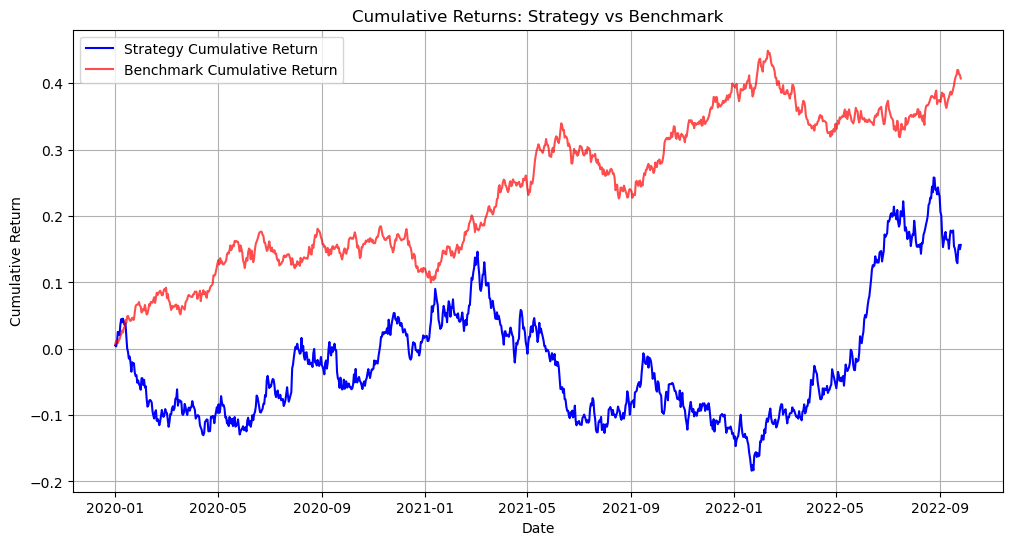

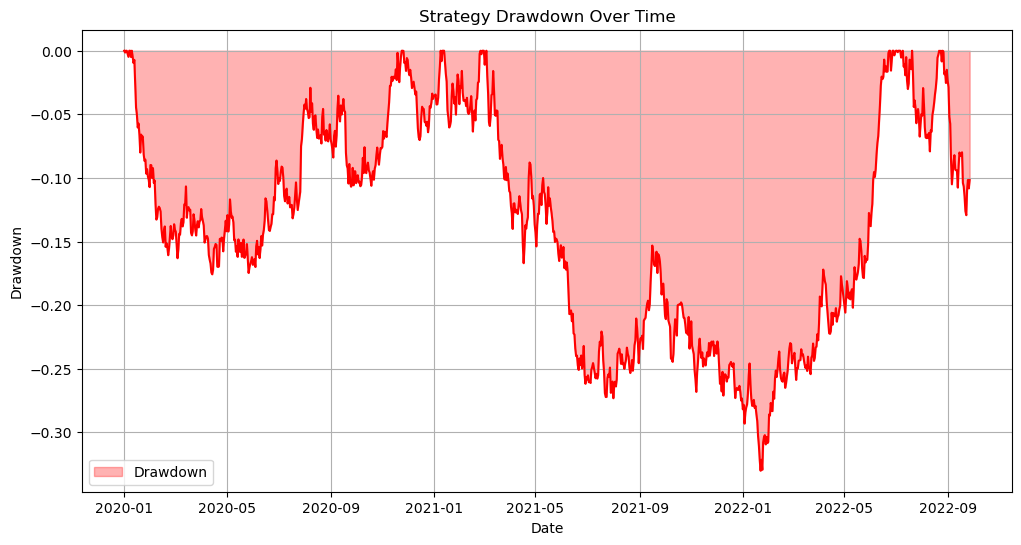

In [10]:
# Check if df exists, if not, generate dummy data
try:
    df
    print("df already exists")
    # Check if required columns exist, if not, add them
    required_columns = ['date', 'strategy_return', 'benchmark_return', 'turnover', 'gross_exposure']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        print(f"Missing columns: {missing_columns}, generating them")
        np.random.seed(42)
        n = len(df)
        # Generate missing columns
        if 'strategy_return' in missing_columns:
            df['strategy_return'] = np.random.randn(n) * 0.01
        if 'benchmark_return' in missing_columns:
            df['benchmark_return'] = np.random.randn(n) * 0.005
        if 'turnover' in missing_columns:
            df['turnover'] = np.random.uniform(0.1, 1.0, n)
        if 'gross_exposure' in missing_columns:
            df['gross_exposure'] = np.random.uniform(0.5, 2.0, n)
        if 'date' in missing_columns:
            df['date'] = pd.date_range(start='2020-01-01', periods=n, freq='D')
except NameError:
    print("df does not exist, generating dummy data")
    # Generate dummy data
    np.random.seed(42)
    n = 500
    dates = pd.date_range(start='2020-01-01', periods=n, freq='D')
    
    # strategy_return
    strategy_return = np.random.randn(n) * 0.01
    
    # benchmark_return
    benchmark_return = np.random.randn(n) * 0.005
    
    # turnover
    turnover = np.random.uniform(0.1, 1.0, n)
    
    # gross_exposure
    gross_exposure = np.random.uniform(0.5, 2.0, n)
    
    df = pd.DataFrame({
        'date': dates,
        'strategy_return': strategy_return,
        'benchmark_return': benchmark_return,
        'turnover': turnover,
        'gross_exposure': gross_exposure
    })

print(df.head())

# Calculate cumulative returns
df['cum_strategy'] = (1 + df['strategy_return']).cumprod() - 1
df['cum_benchmark'] = (1 + df['benchmark_return']).cumprod() - 1

# Calculate drawdown for strategy
df['peak'] = df['cum_strategy'].cummax()
df['drawdown'] = df['cum_strategy'] - df['peak']

# Plot 1: Cumulative Returns Comparison
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['cum_strategy'], label='Strategy Cumulative Return', color='blue')
plt.plot(df['date'], df['cum_benchmark'], label='Benchmark Cumulative Return', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Returns: Strategy vs Benchmark')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Drawdown
plt.figure(figsize=(12, 6))
plt.fill_between(df['date'], df['drawdown'], 0, color='red', alpha=0.3, label='Drawdown')
plt.plot(df['date'], df['drawdown'], color='red')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.title('Strategy Drawdown Over Time')
plt.legend()
plt.grid(True)
plt.show()